In [2]:
import requests as rq
import bs4
import pandas as pd
import plotly.express as px
import io
import numpy as np
import plotly.graph_objects as go

In [3]:
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)'
#Need to set user agent because the default option wasn't working for me
headers = {
    'User-Agent': 'nolandr1 (nolandr1@jh.edu)'
}
page = rq.get(url, headers=headers)
## print out the first 100 characters just to see what it looks like
page.text[0 : 99]

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-l'

In [4]:
bs4page = bs4.BeautifulSoup(page.text, 'html.parser')
tables = bs4page.find('table',{'class':"wikitable"})

gdp = pd.read_html(io.StringIO(str(tables)))

In [5]:
gdp = pd.read_html(io.StringIO(str(tables)))[0]
gdp.head()

,Country/Territory,IMF (2026)[1],World Bank (2024)[6],United Nations (2024)[7]
0,World,123584494,111326370,100834796
1,United States,31821293,28750956,29298000
2,China[n 1],20650754,18743803,18743802
3,Germany,5328184,4685593,4659929
4,India,4515629,3909892,3952244


In [6]:
url = 'https://en.wikipedia.org/w/index.php?title=List_of_countries_by_GDP_(nominal)&oldid=1187446467'
headers = {
    'User-Agent': 'nolandr1 (nolandr1@jh.edu)'
}
page = rq.get(url, headers=headers)
## print out the first 100 characters just to see what it looks like
page.text[0 : 99]

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-l'

In [7]:
bs4page = bs4.BeautifulSoup(page.text, 'html.parser')
all_tables = pd.read_html(io.StringIO(page.text))
old_gdp = all_tables[2]

# Flatten the MultiIndex columns to a single level
old_gdp.columns = old_gdp.columns.get_level_values(1)

#dropping every column except UN region & Country/Territory
old_gdp = old_gdp[['Country/Territory', 'UN region']]
old_gdp.head()

,Country/Territory,UN region
0,World,—
1,United States,Americas
2,China,Asia
3,Germany,Europe
4,Japan,Asia


In [8]:
merge_gdp = pd.merge(gdp, old_gdp, on='Country/Territory')
merge_gdp.head()

,Country/Territory,IMF (2026)[1],World Bank (2024)[6],United Nations (2024)[7],UN region
0,World,123584494,111326370,100834796,—
1,United States,31821293,28750956,29298000,Americas
2,Germany,5328184,4685593,4659929,Europe
3,India,4515629,3909892,3952244,Asia
4,Japan,4463634,4027598,4026211,Asia


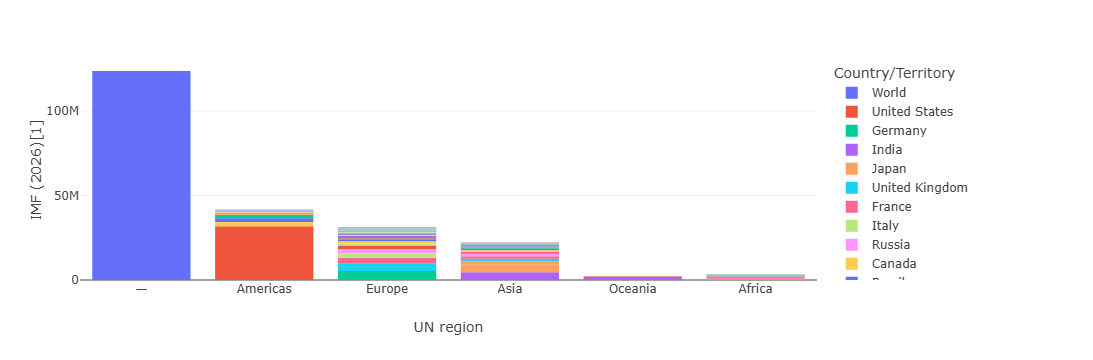

In [11]:
fig = px.bar(merge_gdp, x='UN region', y='IMF (2026)[1]', color='Country/Territory', color_discrete_sequence=px.colors.qualitative.Plotly)
fig.show()
fig.write_html('stacked_bar.html')